In [1]:
import numpy as np
from PIL import Image
import os

def get_cam_chain_index(img_path):
    if not os.path.exists(img_path):
        return None
    
    # Bild laden und in Graustufen umwandeln (Energie-Repräsentation)
    img = Image.open(img_path).convert('L')
    data = np.array(img) / 255.0
    
    # Definition der Zonen (Indizes von oben nach unten im 224px Bild)
    # Zone 1: Hohe Frequenzen (Steuerkette/Ventile) - Oberes Drittel
    chain_zone = data[20:80, :] 
    
    # Zone 2: Mittlere/Tiefe Frequenzen (Motor-Grundbrummen) - Untere Mitte
    engine_zone = data[120:180, :]
    
    chain_energy = np.mean(chain_zone)
    engine_energy = np.mean(engine_zone)
    
    # Index: Verhältnis der "hellen" Energie oben zu unten
    # Ein rasselnder Motor sollte oben im Verhältnis deutlich mehr Energie (hellere Pixel) haben
    return chain_energy / engine_energy

# Deine Test-Files
test_files = {
    "Gesund (S1000RR_2014)": '../data/processed/dataset_idle/S1000RR_2014_MaximilianHohmann_idle_45.25s.png',
    "Gesund (S1000R_2014)": '../data/processed/dataset_idle/S1000R_2014_YoutubeVToldsMotoShow_idle_1.75s.png',
    "Gesund (S1000RR_2012)": '../data/processed/dataset_idle/S1000RR_2012_YoutubeMartinNgim_idle_6.25s.png',
    "Defekt (CC 1 - 5s)": '../data/processed/dataset_idle_defective/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_5.25s.png', 
    "Defekt (CC 1 - 9s)": '../data/processed/dataset_idle_defective/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_9.25s.png', 
    "Defekt (CC 2 - 0s)": '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_0.50s.png',
    "Defekt (CC 2 - 9s)": '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_9.50s.png', 
}

print(f"{'Maschine':<25} | {'Steuerketten-Index':<18}")
print("-" * 50)

for name, path in test_files.items():
    index = get_cam_chain_index(path)
    if index is not None:
        print(f"{name:<25} | {index:>18.4f}")
    else:
        print(f"{name:<25} | Datei nicht gefunden")
def get_chaos_index(img_path):
    img = Image.open(img_path).convert('L')
    data = np.array(img) / 255.0
    
    # Fokus auf die Ketten-Zone
    chain_zone = data[20:80, :]
    
    # Wir messen die Differenz zwischen benachbarten Pixeln (Gradient)
    # Ein rasselndes Signal hat viel mehr scharfe Kanten/Sprünge als ein glattes Rauschen
    chaos = np.mean(np.abs(np.diff(chain_zone, axis=1)))
    return chaos

print(f"{'Maschine':<25} | {'Chaos-Index':<18}")
print("-" * 50)

for name, path in test_files.items():
    index = get_chaos_index(path)
    if index is not None:
        print(f"{name:<25} | {index:>18.4f}")
    else:
        print(f"{name:<25} | Datei nicht gefunden")
import numpy as np
from scipy.stats import kurtosis
from PIL import Image
import os

def get_kurtosis_index(img_path):
    if not os.path.exists(img_path):
        return None
    
    img = Image.open(img_path).convert('L')
    data = np.array(img) / 255.0
    
    # Fokus auf die Ketten-Zone (hohe Frequenzen)
    # Wir schauen uns an, wie "peitschig" die Amplituden über die Zeit verteilt sind
    chain_zone = data[20:100, :] 
    
    # Kurtosis für jede Frequenzzeile berechnen
    # fisher=True bedeutet: Normalverteilung = 0.0
    k_values = [kurtosis(chain_zone[i, :], fisher=True) for i in range(chain_zone.shape[0])]
    
    # Wir nehmen den Maximalwert: Gibt es irgendwo impulsive Schläge?
    return np.max(k_values)

# Deine Test-Files
test_files = {
    "Gesund (S1000RR_2014)": '../data/processed/dataset_idle/S1000RR_2014_MaximilianHohmann_idle_45.25s.png',
    "Gesund (S1000R_2014)": '../data/processed/dataset_idle/S1000R_2014_YoutubeVToldsMotoShow_idle_1.75s.png',
    "Gesund (S1000RR_2012)": '../data/processed/dataset_idle/S1000RR_2012_YoutubeMartinNgim_idle_6.25s.png',
    "Defekt (CC 1 - 5s)": '../data/processed/dataset_idle_defective/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_5.25s.png', 
    "Defekt (CC 1 - 9s)": '../data/processed/dataset_idle_defective/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_9.25s.png', 
    "Defekt (CC 2 - 0s)": '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_0.50s.png',
    "Defekt (CC 2 - 9s)": '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_9.50s.png', 
}

print(f"{'Maschine':<25} | {'Max-Kurtosis (Impuls-Stärke)':<25}")
print("-" * 55)

for name, path in test_files.items():
    k_val = get_kurtosis_index(path)
    if k_val is not None:
        print(f"{name:<25} | {k_val:>25.4f}")
import os
import numpy as np
from scipy.stats import kurtosis
from PIL import Image
import pandas as pd

def get_kurtosis_index(img_path):
    try:
        img = Image.open(img_path).convert('L')
        data = np.array(img) / 255.0
        # Fokus auf die mechanische Zone (Steuerkette/Ventile)
        chain_zone = data[20:100, :] 
        # Kurtosis pro Frequenzzeile
        k_values = [kurtosis(chain_zone[i, :], fisher=True) for i in range(chain_zone.shape[0])]
        return np.max(k_values)
    except Exception as e:
        print(f"Fehler bei {os.path.basename(img_path)}: {e}")
        return None
    
def get_kurtosis_contrast(img_path):
    img = Image.open(img_path).convert('L')
    data = np.array(img) / 255.0
    
    # Zone 1: Mechanik (Oben, 20-100)
    # Zone 2: Referenz/Brummen (Unten, 150-210)
    
    k_top = np.max([kurtosis(data[i, :], fisher=True) for i in range(20, 100)])
    k_bottom = np.max([kurtosis(data[i, :], fisher=True) for i in range(150, 210)])
    
    # Der Kontrast: Wie viel "spitziger" ist die Mechanik im Vergleich zum Rest?
    # Das neutralisiert die Mikrofon-Qualität, da sie beide Zonen betrifft.
    return k_top / (k_bottom + 1e-6)

def run_mass_analysis(healthy_dir, defective_dir, threshold=6.0):
    all_data = []
    
    # Ordner-Konfiguration (Pfade an deine Struktur angepasst)
    folders = [
        (healthy_dir, "Gesund (Referenz)"),
        (defective_dir, "Defekt (Anomalie)")
    ]
    
    print(f"{'Ordner':<20} | {'Datei':<30} | {'Kurtosis':<8} | {'Status'}")
    print("-" * 80)
    
    for folder_path, label in folders:
        if not os.path.exists(folder_path):
            print(f"Warnung: Pfad {folder_path} nicht gefunden.")
            continue
            
        files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        
        for f in sorted(files):
            full_path = os.path.join(folder_path, f)
            k_val = get_kurtosis_contrast(full_path)
            
            if k_val is not None:
                diagnosis = "ALARM (Defekt)" if k_val > threshold else "OK (Gesund)"
                all_data.append({
                    'Ordner': label,
                    'Datei': f,
                    'Kurtosis': k_val,
                    'Diagnose': diagnosis
                })
                print(f"{label[:20]:<20} | {f[:30]:<30} | {k_val:>8.2f} | {diagnosis}")

    # Zusammenfassung als DataFrame für die Analyse
    df = pd.DataFrame(all_data)
    print("\n" + "="*30)
    print("STATISTISCHE AUSWERTUNG")
    print("="*30)
    summary = df.groupby(['Ordner', 'Diagnose']).size().unstack(fill_value=0)
    print(summary)
    
    return df

# --- Durchführung ---
# Achte auf die korrekten Pfadnamen (du hattest 'dataset_idle_defect' geschrieben)
healthy_path = '../data/processed/dataset_idle/'
defective_path = '../data/processed/dataset_idle_defective/'

results_df = run_mass_analysis(healthy_path, defective_path, threshold=6.0)
import os
import numpy as np
from scipy.stats import kurtosis
from scipy.ndimage import gaussian_filter
from PIL import Image
import pandas as pd

def get_robust_kurtosis_contrast(img_path):
    try:
        img = Image.open(img_path).convert('L')
        data = np.array(img) / 255.0
        
        # NEU: Ein leichter Blur (Sigma=1), um die High-Fi-Spitzen zu glätten
        # Das simuliert die YouTube-Glättung für deine Garagen-Daten
        data = gaussian_filter(data, sigma=1)
        
        # Zonen wie gehabt
        chain_zone = data[20:100, :]
        engine_zone = data[150:210, :]
        
        # Kurtosis pro Zeile
        k_top = [kurtosis(chain_zone[i, :], fisher=True) for i in range(chain_zone.shape[0])]
        k_bottom = [kurtosis(engine_zone[i, :], fisher=True) for i in range(engine_zone.shape[0])]
        
        # NEU: 95. Perzentil statt Max (viel robuster gegen Einzelpixel-Fehler)
        p95_top = np.percentile(k_top, 95)
        p95_bottom = np.percentile(k_bottom, 95)
        
        return p95_top / (p95_bottom + 1e-6)
    except:
        return None

def run_final_validation(healthy_dir, defective_dir, threshold=2.5): # Höherer Threshold!
    all_data = []
    folders = [(healthy_dir, "Gesund"), (defective_dir, "Defekt")]
    
    for path, label in folders:
        if not os.path.exists(path): continue
        files = [f for f in os.listdir(path) if f.endswith('.png')]
        for f in files:
            ratio = get_robust_kurtosis_contrast(os.path.join(path, f))
            if ratio is not None:
                diag = "ALARM" if ratio > threshold else "OK"
                all_data.append({'Ordner': label, 'Ratio': ratio, 'Diagnose': diag})

    df = pd.DataFrame(all_data)
    print(f"\nVALIDIERUNG (Robust-Kontrast | Threshold: {threshold})")
    summary = df.groupby(['Ordner', 'Diagnose']).size().unstack(fill_value=0)
    print(summary)
    
    # Durchschnittswerte anzeigen
    print("\nDurchschnittliche Ratio pro Gruppe:")
    print(df.groupby('Ordner')['Ratio'].mean())
    return df

# Start der Analyse
results_df = run_final_validation('../data/processed/dataset_idle/', 
                                 '../data/processed/dataset_idle_defective/', 
                                 threshold=2.5)

Maschine                  | Steuerketten-Index
--------------------------------------------------
Gesund (S1000RR_2014)     |             0.8403
Gesund (S1000R_2014)      |             0.6677
Gesund (S1000RR_2012)     |             0.6915
Defekt (CC 1 - 5s)        |             0.5306
Defekt (CC 1 - 9s)        |             0.5244
Defekt (CC 2 - 0s)        |             0.8178
Defekt (CC 2 - 9s)        |             0.8753
Maschine                  | Chaos-Index       
--------------------------------------------------
Gesund (S1000RR_2014)     |             0.0129
Gesund (S1000R_2014)      |             0.0101
Gesund (S1000RR_2012)     |             0.0101
Defekt (CC 1 - 5s)        |             0.0102
Defekt (CC 1 - 9s)        |             0.0102
Defekt (CC 2 - 0s)        |             0.0133
Defekt (CC 2 - 9s)        |             0.0143
Maschine                  | Max-Kurtosis (Impuls-Stärke)
-------------------------------------------------------
Gesund (S1000RR_2014)     |      

Gesund (S1000RR_2014) | Peak-Instability: 0.008823 | Total: 0.5792
Gesund (S1000R_2014) | Peak-Instability: 0.003012 | Total: 0.3952
Gesund (S1000RR_2012) | Peak-Instability: 0.003617 | Total: 0.4172
Defekt (Cam Chain 1) | Peak-Instability: 0.002539 | Total: 0.3783
Defekt (Cam Chain 2) | Peak-Instability: 0.006312 | Total: 0.8121


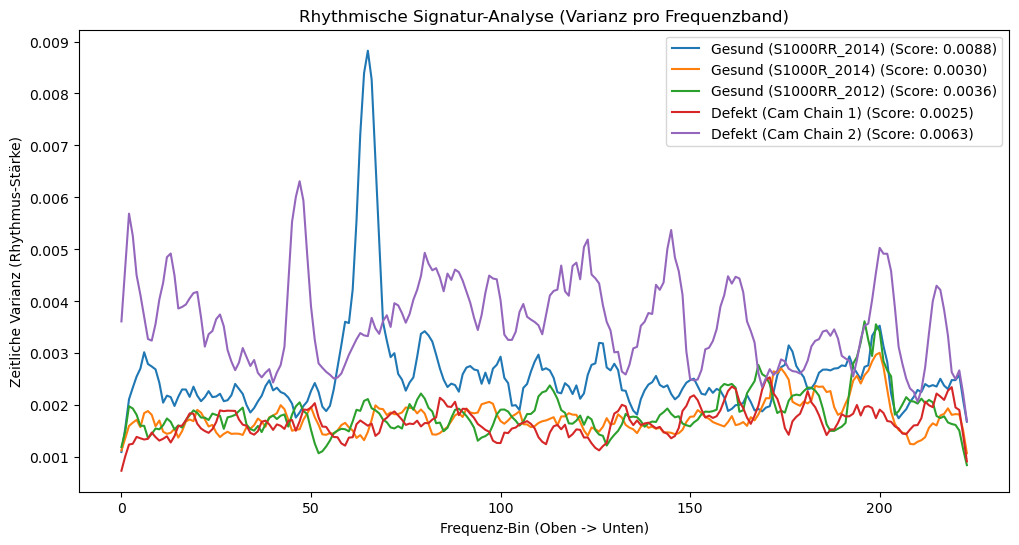

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def analyze_rhythmic_anomaly(img_path):
    # 1. Bild laden und in Graustufen (Energie) umwandeln
    img = Image.open(img_path).convert('L')
    data = np.array(img) / 255.0  # Normalisieren
    
    # 2. Wir analysieren die Varianz entlang der Zeitachse (horizontale Achse)
    # Ein hoher Wert bedeutet: In diesem Frequenzband "passiert" rhythmisch viel
    variance_per_freq = np.var(data, axis=1) 
    
    # 3. Wir glätten das Ergebnis, um Rauschen zu unterdrücken
    kernel_size = 5
    smoothed_variance = np.convolve(variance_per_freq, np.ones(kernel_size)/kernel_size, mode='same')
    
    # 4. Frequenzbereiche definieren (Index im Bild von oben nach unten)
    # Bei 224 Pixeln entsprechen die oberen Indizes den hohen Frequenzen
    high_freq_area = smoothed_variance[0:100] # Oben (Kettengeräusche/Ventile)
    low_freq_area = smoothed_variance[150:224] # Unten (Lagerklopfen/Verbrennung)
    
    total_instability = np.sum(smoothed_variance)
    peak_instability = np.max(smoothed_variance)
    
    return smoothed_variance, total_instability, peak_instability

# --- Vergleich ausführen ---
test_files = {
    "Gesund (S1000RR_2014)": '../data/processed/dataset_idle/S1000RR_2014_MaximilianHohmann_idle_45.25s.png',
    "Gesund (S1000R_2014)": '../data/processed/dataset_idle/S1000R_2014_YoutubeVToldsMotoShow_idle_1.75s.png',
    "Gesund (S1000RR_2012)": '../data/processed/dataset_idle/S1000RR_2012_YoutubeMartinNgim_idle_6.25s.png',
    "Defekt (Cam Chain 1)": '../data/processed/dataset_idle_defective/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_5.25s.png', 
    "Defekt (Cam Chain 1)": '../data/processed/dataset_idle_defective/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle_idle_9.25s.png', 
    "Defekt (Cam Chain 2)": '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_0.50s.png',
    "Defekt (Cam Chain 2)": '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_9.50s.png', 
}


plt.figure(figsize=(12, 6))

for name, path in test_files.items():
    variance, total, peak = analyze_rhythmic_anomaly(path)
    plt.plot(variance, label=f"{name} (Score: {peak:.4f})")
    print(f"{name:<20} | Peak-Instability: {peak:.6f} | Total: {total:.4f}")

plt.title("Rhythmische Signatur-Analyse (Varianz pro Frequenzband)")
plt.xlabel("Frequenz-Bin (Oben -> Unten)")
plt.ylabel("Zeitliche Varianz (Rhythmus-Stärke)")
plt.legend()
plt.show()